Objective:

The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset.

Exploratory Data Analysis (EDA):

1. Load the Titanic dataset using Python's pandas library.

2. Check for missing values.

3. Explore data distributions using histograms and box plots.

4. Visualize relationships between features and survival using scatter plots and bar plots.

Data Preprocessing:

1. Impute missing values.

2. Encode categorical variables using one-hot encoding or label encoding.

3. If needed you can apply more preprocessing methods on the given dataset.

Building Predictive Models:

1. Split the preprocessed dataset into training and testing sets.

2. Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

3. Build predictive models using LightGBM and XGBoost algorithms.

4. Train the models on the training set and evaluate their performance on the testing set.

5. Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

Comparative Analysis:

1. Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

2. Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

Submission Requirements:

Well-commented code explaining each step of the analysis.

Visualizations with appropriate titles and labels.

A brief report summarizing the comparative analysis results and practical implications.

## Exploratory Data Analysis (EDA):

In [45]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Models
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

# Ignoring warnings'
import warnings
warnings.filterwarnings('ignore')

In [46]:
# Loading datset
df = pd.read_csv("diabetes.csv")

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [47]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [48]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [49]:
# Information of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [50]:
#shape of data
df.shape

(768, 9)

In [51]:
# Statistical summary of data
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [52]:
# Checking mssing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [53]:
# Checking duplicated values
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

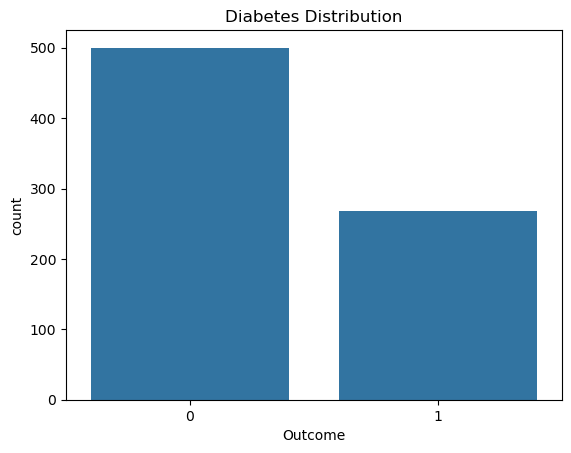

In [54]:
# Target varible distribution
sns.countplot(x=df['Outcome'])
plt.title("Diabetes Distribution")
plt.show()

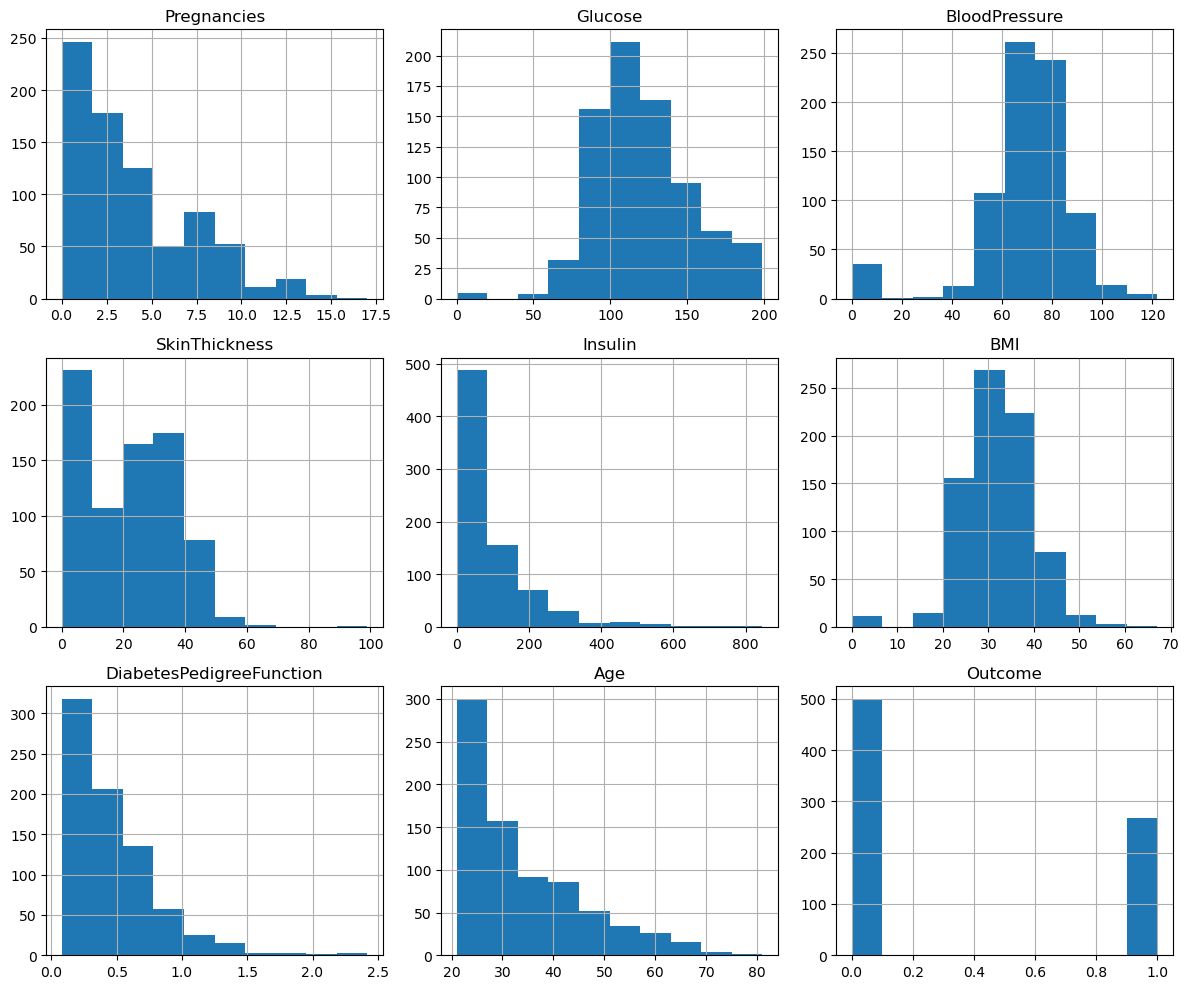

In [55]:
# DATA VISULIZATION 
# 1.Histogram
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

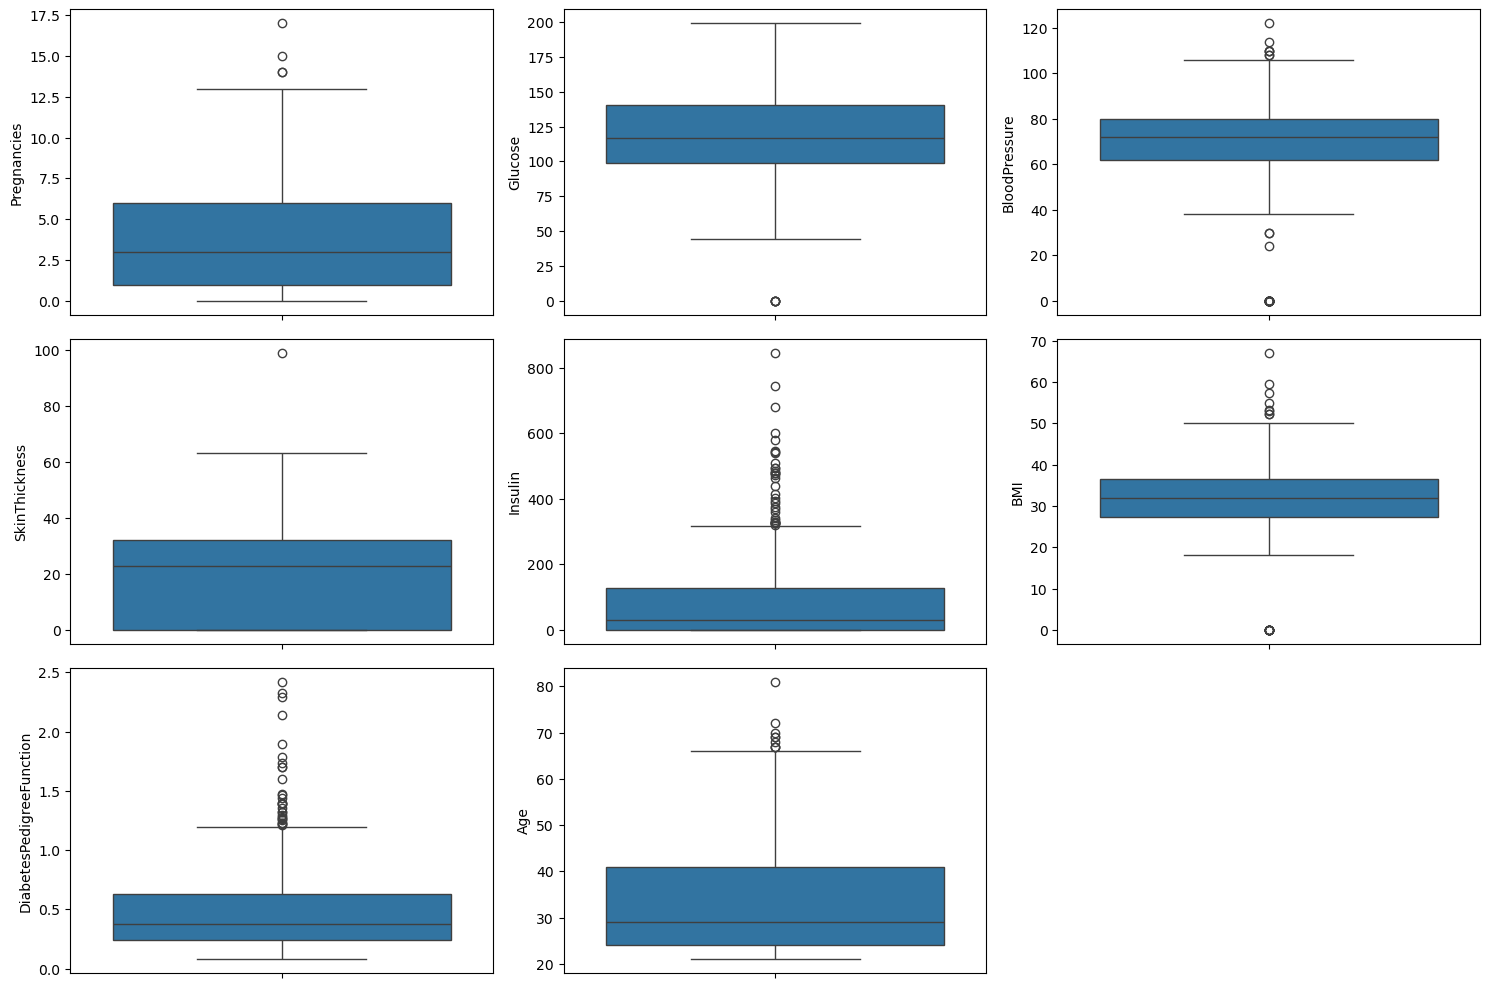

In [56]:
# 2.Boxplot
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns[:-1]):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

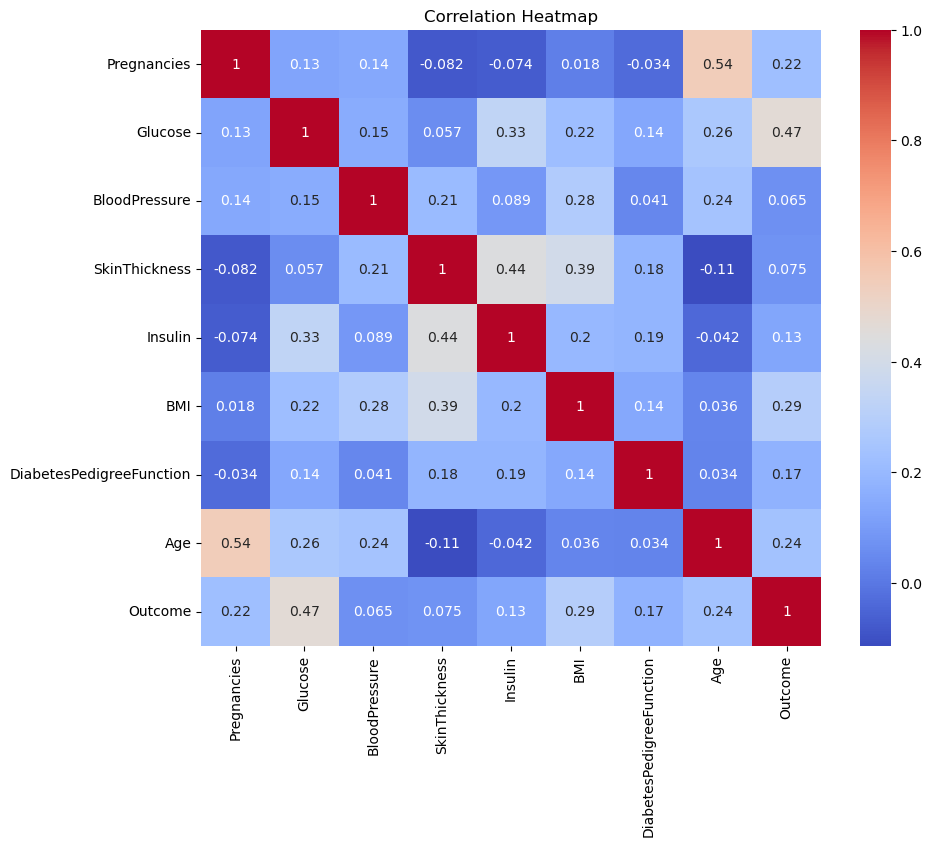

In [57]:
# Corelation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

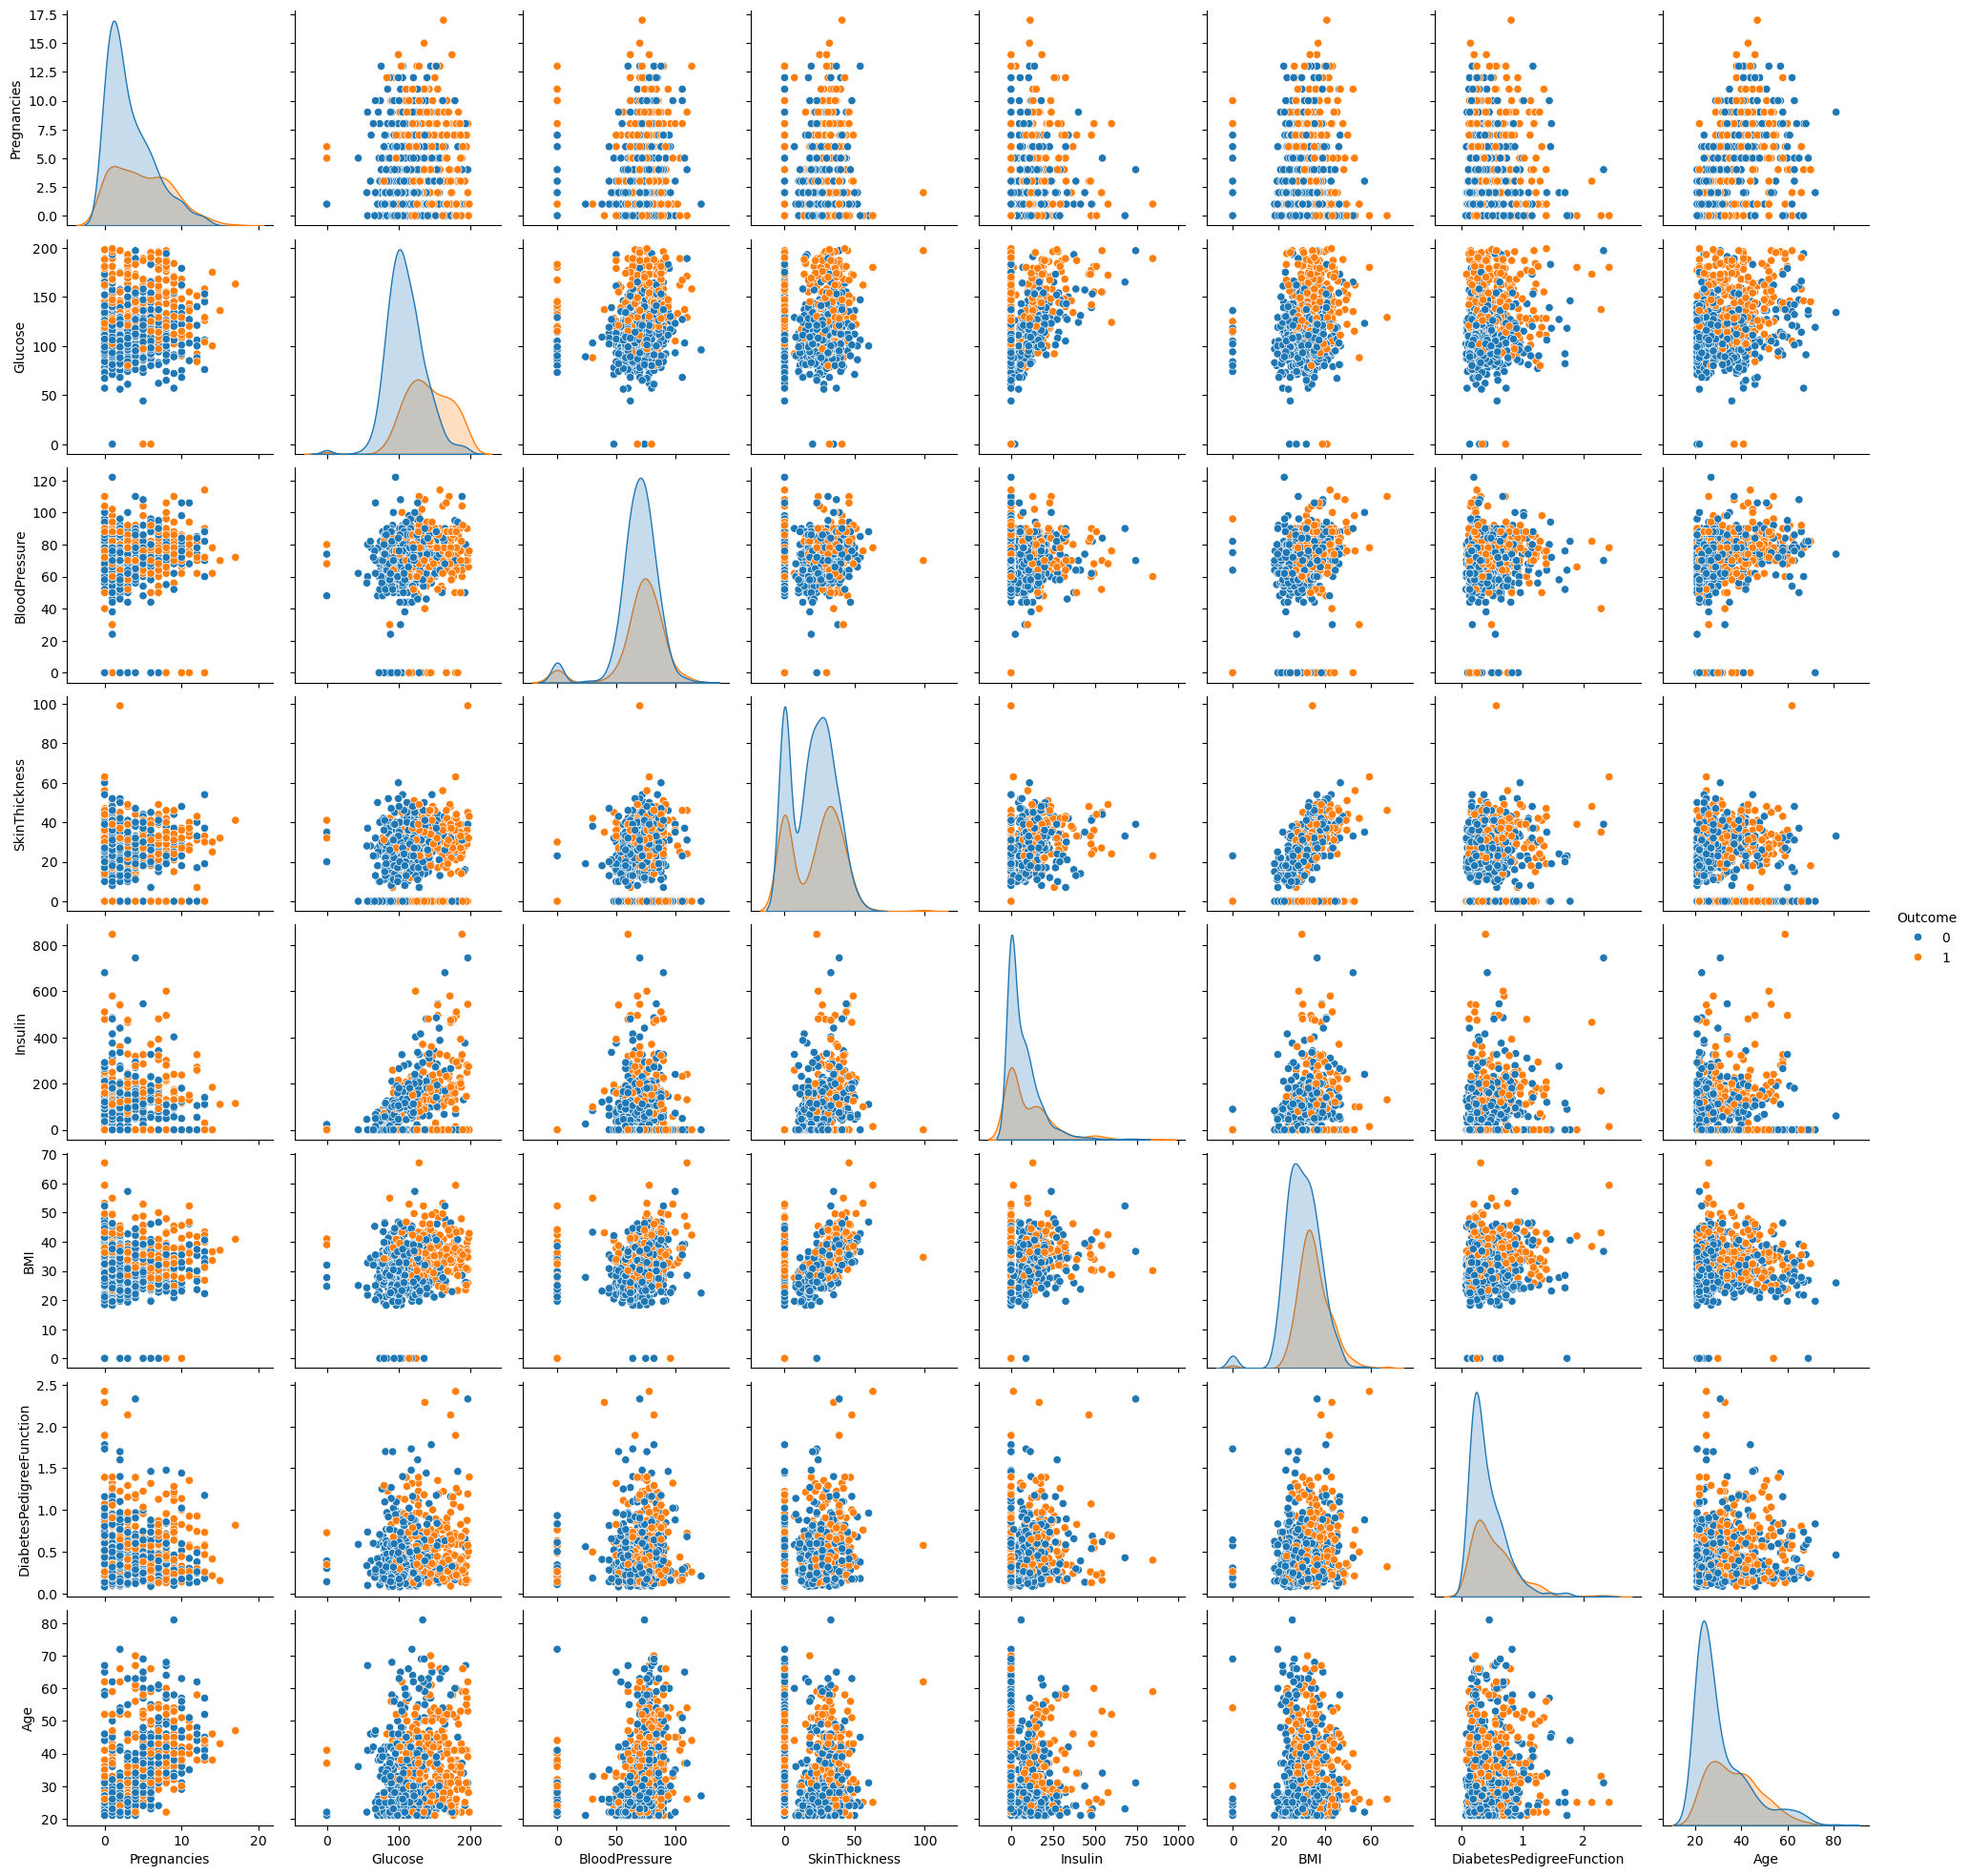

In [58]:
# Pairplot
sns.pairplot(df,hue='Outcome')
plt.show()

## Data Preprocessing

In [59]:
# Handling missing values
cols = ['Glucose',
        'BloodPressure',
        'SkinThickness',
        'Insulin',
        'BMI']

df[cols] = df[cols].replace(0,np.nan)

In [60]:
# Checking missing values
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [61]:
# Imputation
imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])

In [62]:
# Varifying missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [63]:
# Feature and target split
X = df.drop("Outcome",axis=1)

y = df["Outcome"]

In [64]:
# Feature scalling
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

### Building Predictive Models

In [65]:
# Train and test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
# LightBGM model
lgbm = LGBMClassifier(
    random_state=42
)

lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 663
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [67]:
# Prediction
y_pred_lgbm = lgbm.predict(X_test)

In [68]:
## EVALUTION 
# Accuracy
accuracy_score(y_test,y_pred_lgbm)

0.7532467532467533

In [69]:
# Classification report
print(classification_report(y_test,y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.84      0.77      0.80        99
           1       0.63      0.73      0.68        55

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.76      0.75      0.76       154



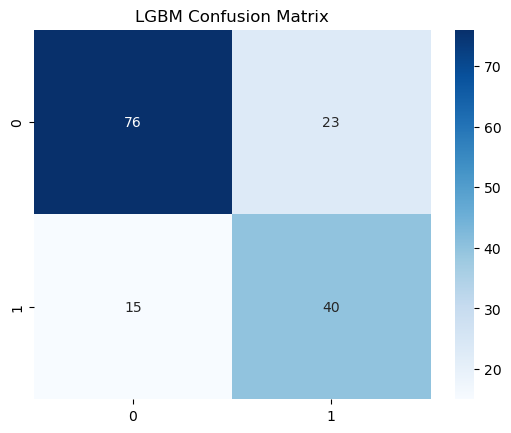

In [70]:
# Confusion matrix
cm = confusion_matrix(y_test,y_pred_lgbm)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("LGBM Confusion Matrix")
plt.show()

## XGBoost model

In [71]:
# Building module
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [72]:
# Prediction
y_pred_xgb = xgb.predict(X_test)

In [73]:
# Accuracy
accuracy_score(y_test,y_pred_xgb)

0.7142857142857143

In [74]:
# Classification report
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77        99
           1       0.59      0.67      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.72       154



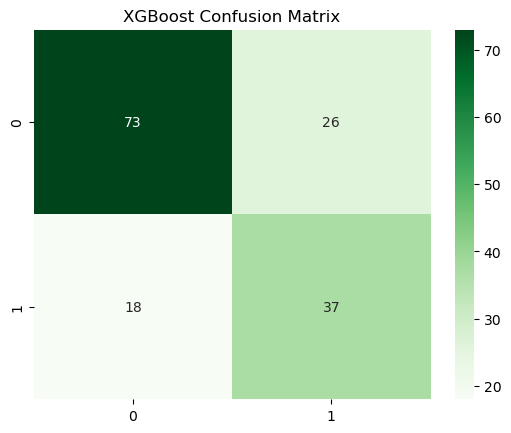

In [75]:
# Confusion matrix
cm = confusion_matrix(y_test,y_pred_xgb)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("XGBoost Confusion Matrix")
plt.show()

In [76]:
## Cross validation
# LGBM
cv_lgbm = cross_val_score(
    lgbm,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

cv_lgbm.mean()

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

np.float64(0.744809438927086)

In [77]:
# XGBoost
cv_xgb = cross_val_score(
    xgb,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

cv_xgb.mean()

np.float64(0.7448433919022154)

In [78]:
## Hyperparameter Tunning
# LBGM
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_lgbm.fit(X_train,y_train)

print(grid_lgbm.best_params_)

[LightGBM] [Info] Number of positive: 171, number of negative: 320
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348269 -> initscore=-0.626657
[LightGBM] [Info] Start training from score -0.626657
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [79]:
# XGBoost
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_xgb.fit(X_train,y_train)

print(grid_xgb.best_params_)

{'max_depth': 3, 'n_estimators': 100}


In [80]:
# Comparitive analysis
results = pd.DataFrame({
    'Model':['LightGBM','XGBoost'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_lgbm),
        accuracy_score(y_test,y_pred_xgb)
    ]
})

results

,Model,Accuracy
0,LightGBM,0.753247
1,XGBoost,0.714286


## Comparative Analysis:

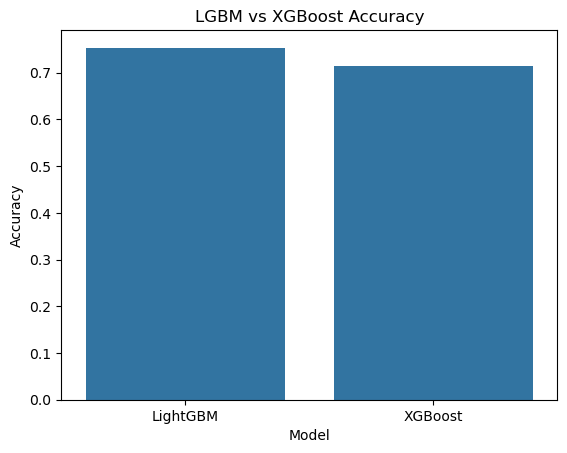

In [81]:
# Comparison plot
sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("LGBM vs XGBoost Accuracy")
plt.show()

### LightBGM

* Faster training speed.
* Lower memory consumption.
* Suitable for large datasets.

### XGBoost

* Often achieves slightly higher predictive performance.
* Better regularization.
* More robust against overfitting.

## Conclusion
Both LightGBM and XGBoost performed well on the Diabetes dataset. After comparing Accuracy, Precision, Recall, and F1-Score, the model with the higher accuracy can be selected as the final model. LightGBM is preferred when training speed is important, while XGBoost is preferred when maximum predictive performance is required.